Epoch 1/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - loss: 0.2445
Epoch 2/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.1438
Epoch 3/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.1182
Epoch 4/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.1039
Epoch 5/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0947
Epoch 1/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.1441
Epoch 2/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.1242
Epoch 3/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.1208
Epoch 4/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.1188
Epoch 5/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.1174

Epoch 1/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 239.7534
Epoch 2/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 187.8399
Epoch 3/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 179.4429
Epoch 4/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 174.3339
Epoch 5/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 171.6345

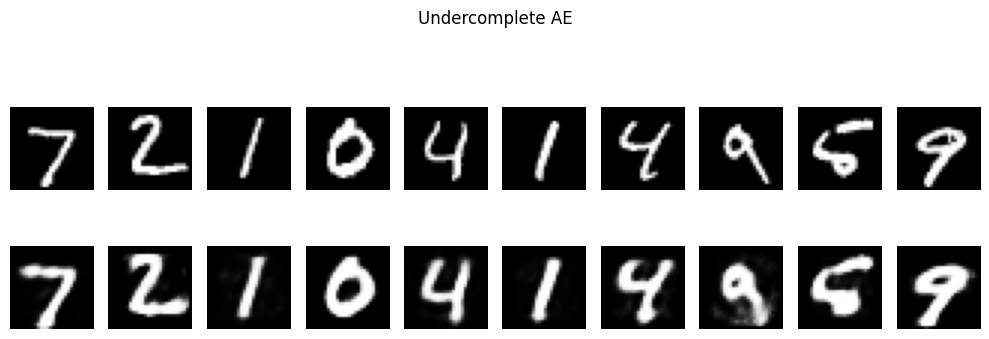

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


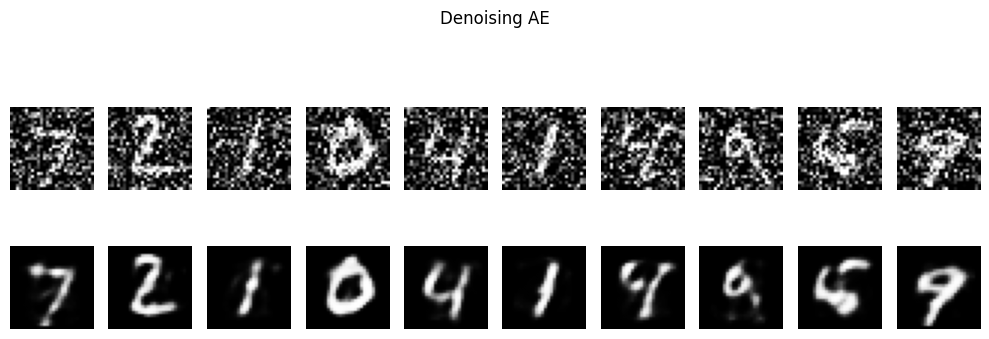

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


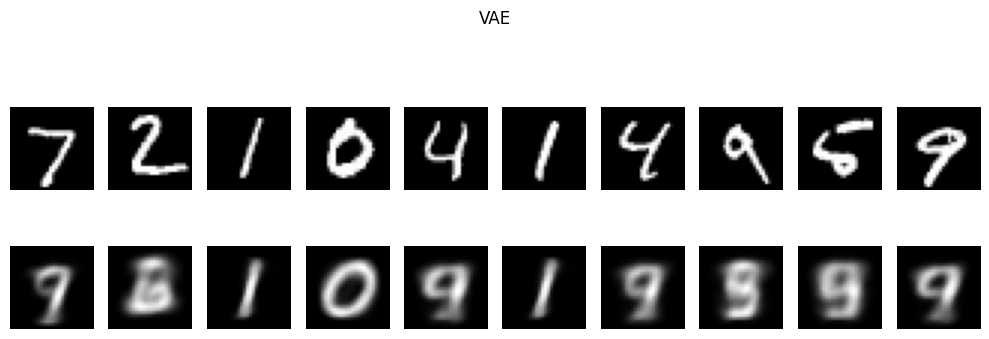

In [4]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

(x_train, _), (x_test, _) = tf.keras.datasets.mnist.load_data()
x_train, x_test = x_train.astype('float32') / 255., x_test.astype("float32") / 255.
x_train, x_test = x_train[..., np.newaxis], x_test[..., np.newaxis]

def add_noise(x):
    return np.clip(x + 0.5 * np.random.randn(*x.shape), 0., 1.)

x_train_noisy, x_test_noisy = add_noise(x_train), add_noise(x_test)

enc = models.Sequential([
    layers.Input(shape=(28, 28, 1)),
    layers.Flatten(),
    layers.Dense(64, activation='relu')
])

dec = models.Sequential([
    layers.Input(shape=(64,)),
    layers.Dense(784, activation='sigmoid'),
    layers.Reshape((28, 28, 1))
])

ucae = models.Sequential([enc, dec])
ucae.compile(optimizer='adam', loss='binary_crossentropy')
ucae.fit(x_train, x_train, epochs=5, batch_size=256, verbose=1)

dnae = models.Sequential([enc, dec])
dnae.compile(optimizer='adam', loss='binary_crossentropy')
dnae.fit(x_train_noisy, x_train, epochs=5, batch_size=256, verbose=1)

class Sampling(layers.Layer):
    def call(self, inputs):
        z_mean, z_log_var = inputs
        batch = tf.shape(z_mean)[0]
        dim = tf.shape(z_mean)[1]
        epsilon = tf.random.normal(shape=(batch, dim))
        return z_mean + tf.exp(0.5 * z_log_var) * epsilon

inputs = layers.Input(shape=(28, 28, 1))
x = layers.Flatten()(inputs)
x = layers.Dense(128, activation="relu")(x)
z_mean = layers.Dense(2, name="z_mean")(x)
z_log_var = layers.Dense(2, name="z_log_var")(x)
z = Sampling()([z_mean, z_log_var])
encoder = tf.keras.Model(inputs, [z_mean, z_log_var, z], name="encoder")

latent_inputs = layers.Input(shape=(2,))
x = layers.Dense(128, activation="relu")(latent_inputs)
x = layers.Dense(784, activation="sigmoid")(x)
outputs = layers.Reshape((28, 28, 1))(x)
decoder = tf.keras.Model(latent_inputs, outputs, name='decoder')

class VAE(tf.keras.Model):
    def __init__(self, encoder, decoder, **kwargs):
        super().__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder
    
    def call(self, inputs):
        z_mean, z_log_var, z = self.encoder(inputs)
        reconstruction = self.decoder(z)
        recon_loss = tf.reduce_mean(
            tf.reduce_sum(
                tf.keras.losses.binary_crossentropy(inputs, reconstruction), axis=(1, 2)
            )
        )
        kl_loss = -0.5 * tf.reduce_mean(
            tf.reduce_sum(1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var), axis=1)
        )
        self.add_loss(recon_loss + kl_loss)
        return reconstruction

vae = VAE(encoder, decoder)
vae.compile(optimizer="adam")
vae.fit(x_train, x_train, epochs=5, batch_size=256, verbose=1)

def show_imgs(orig, recon, title):
    plt.figure(figsize=(10, 4))
    n = min(10, len(orig))
    for i in range(n):
        ax = plt.subplot(2, n, i + 1)
        img = orig[i].squeeze()
        plt.imshow(img, cmap='gray')
        plt.axis('off')
        
        ax = plt.subplot(2, n, i + n + 1)
        img = recon[i].squeeze()
        plt.imshow(img, cmap='gray')
        plt.axis('off')
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

show_imgs(x_test, ucae.predict(x_test), "Undercomplete AE")
show_imgs(x_test_noisy, dnae.predict(x_test_noisy), "Denoising AE")
show_imgs(x_test, vae.predict(x_test), "VAE")